# Eval Plots — PlanningOrchestrator Benchmark
Laadt MLflow child-runs, groepeert per **agent group** (graph / salesforce / smartsales / orchestrator)
en toont scores, latency, tokens en rationale — vergelijkbaar met de Excel benchmark.

In [191]:
import mlflow
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from IPython.display import display

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
print('imports ok')

imports ok


In [192]:
# ── Config ────────────────────────────────────────────────────────────────────
TRACKING_URI = 'sqlite:///C:/Users/AALB/Desktop/mp/graph/graphxmaf/mlflow.db'
EXPERIMENT   = 'graphxmaf-eval'

# Category → agent group (zelfde indeling als Excel)
AGENT_GROUPS = {
    'graph':        ['email', 'calendar', 'files', 'people', 'identity'],
    'salesforce':   ['accounts', 'contacts', 'leads', 'opportunities', 'cases'],
    'smartsales':   ['locations', 'catalog', 'orders'],
    'orchestrator': ['cross-system'],
}

GROUP_ORDER  = ['graph', 'salesforce', 'smartsales', 'orchestrator']
GROUP_COLORS = {
    'graph':        '#3b82f6',
    'salesforce':   '#10b981',
    'smartsales':   '#f59e0b',
    'orchestrator': '#8b5cf6',
}

DIFFICULTY_ORDER = ['simple', 'medium', 'hard']
DIFF_COLORS      = {'simple': '#93c5fd', 'medium': '#3b82f6', 'hard': '#1e3a8a'}

# Geschatte GPT-4o prijs (USD per 1 000 tokens)
COST_IN_PER_1K  = 0.0025
COST_OUT_PER_1K = 0.010

In [193]:
# ── Data laden ────────────────────────────────────────────────────────────────
mlflow.set_tracking_uri(TRACKING_URI)
exp = mlflow.get_experiment_by_name(EXPERIMENT)
if exp is None:
    raise RuntimeError(f'Experiment "{EXPERIMENT}" niet gevonden. Eerst mlflow_eval.py runnen.')

raw = mlflow.search_runs(
    experiment_ids=[exp.experiment_id],
    filter_string='tags.mlflow.parentRunId != ""',
    output_format='pandas',
)

RENAME = {
    'metrics.llm_score':          'llm_score',
    'metrics.routing_score':      'routing_score',
    'metrics.latency_s':          'latency_s',
    'metrics.total_tokens':       'total_tokens',
    'metrics.input_tokens':       'input_tokens',
    'metrics.output_tokens':      'output_tokens',
    'metrics.routing_precision':  'routing_precision',
    'metrics.routing_recall':     'routing_recall',
    'metrics.plan_steps':         'plan_steps',
    'metrics.parallel_ratio':     'parallel_ratio',
    'metrics.success':            'success',
    'tags.version':               'version',
    'tags.category':              'category',
    'tags.difficulty':            'difficulty',
    'tags.mlflow.runName':        'run_name',
    'tags.llm_rationale':         'llm_rationale',
    'tags.routing_rationale':     'routing_rationale',
    'tags.llm_comments':          'llm_comments',
    'params.query':               'query',
    'params.expected_agents':     'expected_agents',
}

df = raw.rename(columns={k: v for k, v in RENAME.items() if k in raw.columns})

CAT_TO_GROUP  = {cat: grp for grp, cats in AGENT_GROUPS.items() for cat in cats}
df['agent_group'] = df['category'].map(CAT_TO_GROUP).fillna('unknown')
df['difficulty']  = pd.Categorical(df['difficulty'], categories=DIFFICULTY_ORDER, ordered=True)

# Geschatte kost per run
df['cost_usd'] = (
    df.get('input_tokens',  pd.Series(0, index=df.index)).fillna(0) / 1000 * COST_IN_PER_1K +
    df.get('output_tokens', pd.Series(0, index=df.index)).fillna(0) / 1000 * COST_OUT_PER_1K
)

VERSIONS   = sorted(df['version'].dropna().unique())
N_VERSIONS = len(VERSIONS)

print(f'Geladen   : {len(df)} child-runs')
print(f'Versies   : {VERSIONS}')
print(f'Groepen   : {df["agent_group"].value_counts().to_dict()}')
print(f'Succesvol : {df["success"].mean():.0%}  (n={int(df["success"].notna().sum())})')

Geladen   : 76 child-runs
Versies   : ['baseline']
Groepen   : {'salesforce': 24, 'smartsales': 22, 'graph': 20, 'orchestrator': 9, 'unknown': 1}
Succesvol : 100%  (n=75)


## 1. Samenvattingstabel per agent group

In [194]:
def _agg(g):
    return pd.Series({
        'N':               len(g),
        'LLM score':       round(g['llm_score'].mean(), 2),
        'Routing score':   round(g['routing_score'].mean(), 2),
        'Precision':       round(g['routing_precision'].mean(), 2),
        'Recall':          round(g['routing_recall'].mean(), 2),
        'Success':         round(g['success'].mean(), 2),
        'Latency avg (s)': round(g['latency_s'].mean(), 1),
        'Latency p95 (s)': round(g['latency_s'].quantile(0.95), 1),
        'Tokens avg':      int(g['total_tokens'].mean()) if g['total_tokens'].notna().any() else 0,
        'Cost avg (ct)':   round(g['cost_usd'].mean() * 100, 3),
    })

summary = (
    df.groupby(['version', 'agent_group'])
    .apply(_agg)
    .reset_index()
    .set_index(['version', 'agent_group'])
)

# Volgorde forceren
idx = pd.MultiIndex.from_product([VERSIONS, GROUP_ORDER], names=['version', 'agent_group'])
summary = summary.reindex(idx).dropna(how='all')

display(
    summary.style
    .format(precision=2)
    .background_gradient(subset=['LLM score', 'Routing score'], cmap='RdYlGn', vmin=1, vmax=5)
    .background_gradient(subset=['Precision', 'Recall', 'Success'], cmap='RdYlGn', vmin=0, vmax=1)
    .set_caption('Gemiddelden per versie × agent group')
)

C:\Users\AALB\AppData\Local\Temp\ipykernel_25672\3774476897.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_agg)


## 2. LLM Score & Routing Score per agent group

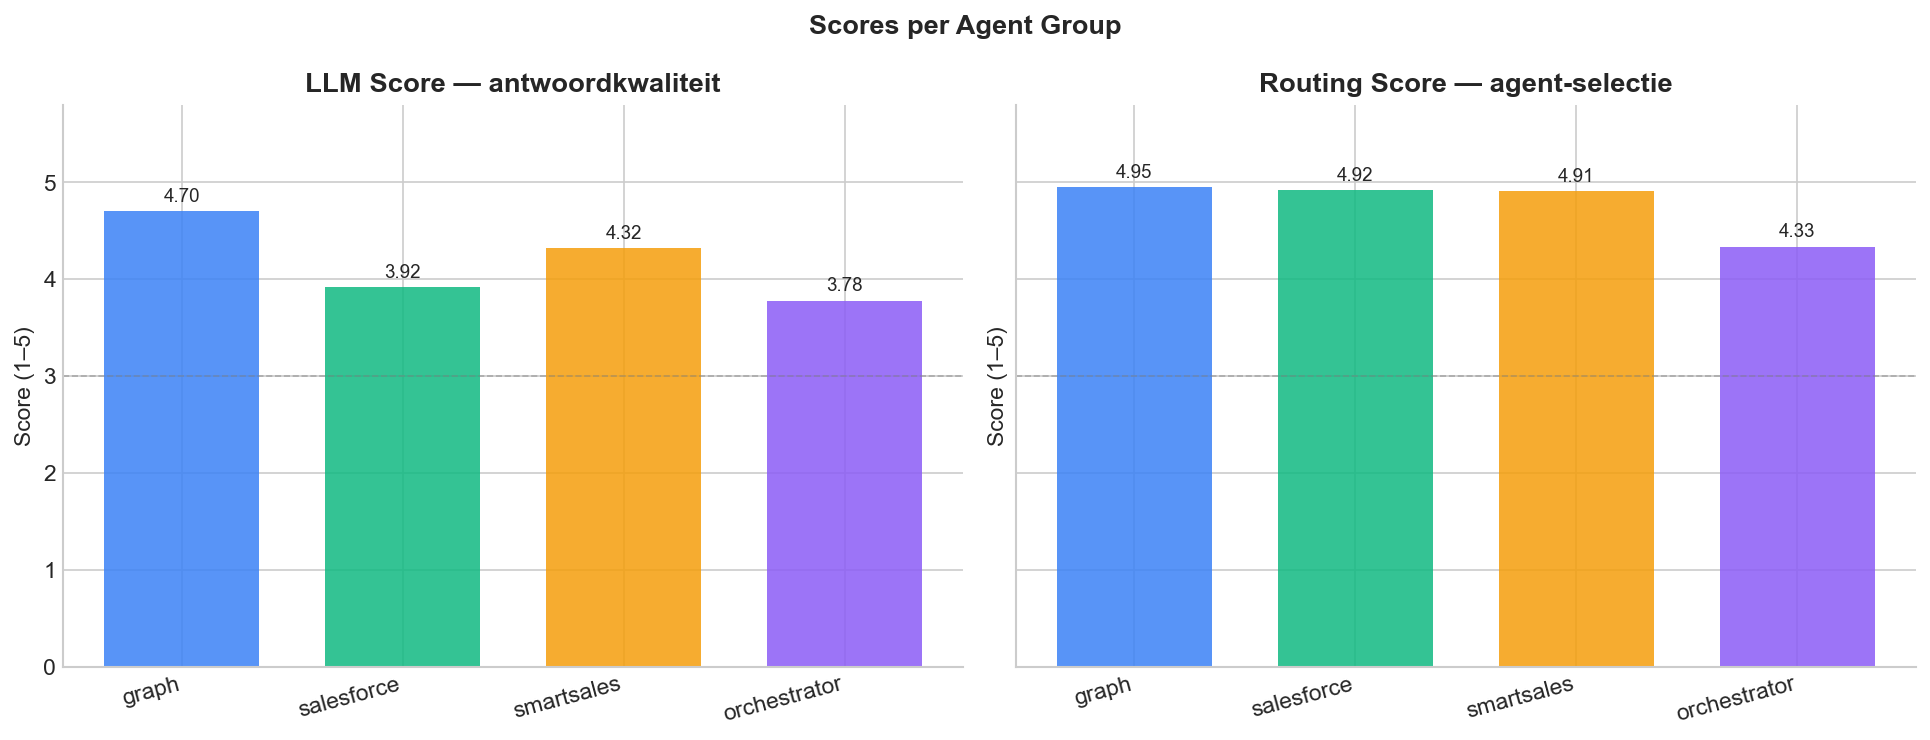

In [195]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax_idx, (metric, title) in enumerate([
    ('llm_score',     'LLM Score — antwoordkwaliteit'),
    ('routing_score', 'Routing Score — agent-selectie'),
]):
    ax  = axes[ax_idx]
    x   = np.arange(len(GROUP_ORDER))
    bar_w = 0.7 / max(N_VERSIONS, 1)

    for v_idx, version in enumerate(VERSIONS):
        vdf  = df[df['version'] == version]
        vals = [vdf[vdf['agent_group'] == g][metric].mean() for g in GROUP_ORDER]
        off  = (v_idx - (N_VERSIONS - 1) / 2) * bar_w
        bars = ax.bar(
            x + off, vals, bar_w,
            label=version,
            color=[GROUP_COLORS[g] for g in GROUP_ORDER] if N_VERSIONS == 1 else None,
            alpha=0.85,
        )
        for bar, val in zip(bars, vals):
            if not (val != val):  # not NaN
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.06,
                        f'{val:.2f}', ha='center', va='bottom', fontsize=9)

    ax.set_xticks(x)
    ax.set_xticklabels(GROUP_ORDER, rotation=15, ha='right')
    ax.set_ylim(0, 5.8)
    ax.set_ylabel('Score (1–5)')
    ax.set_title(title, fontweight='bold')
    ax.axhline(3, ls='--', color='gray', lw=0.8, alpha=0.5)
    if N_VERSIONS > 1:
        ax.legend()

plt.suptitle('Scores per Agent Group', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('plot_scores_per_group.png', bbox_inches='tight')
plt.show()

## 3. Score per categorie (binnen elke agent group)

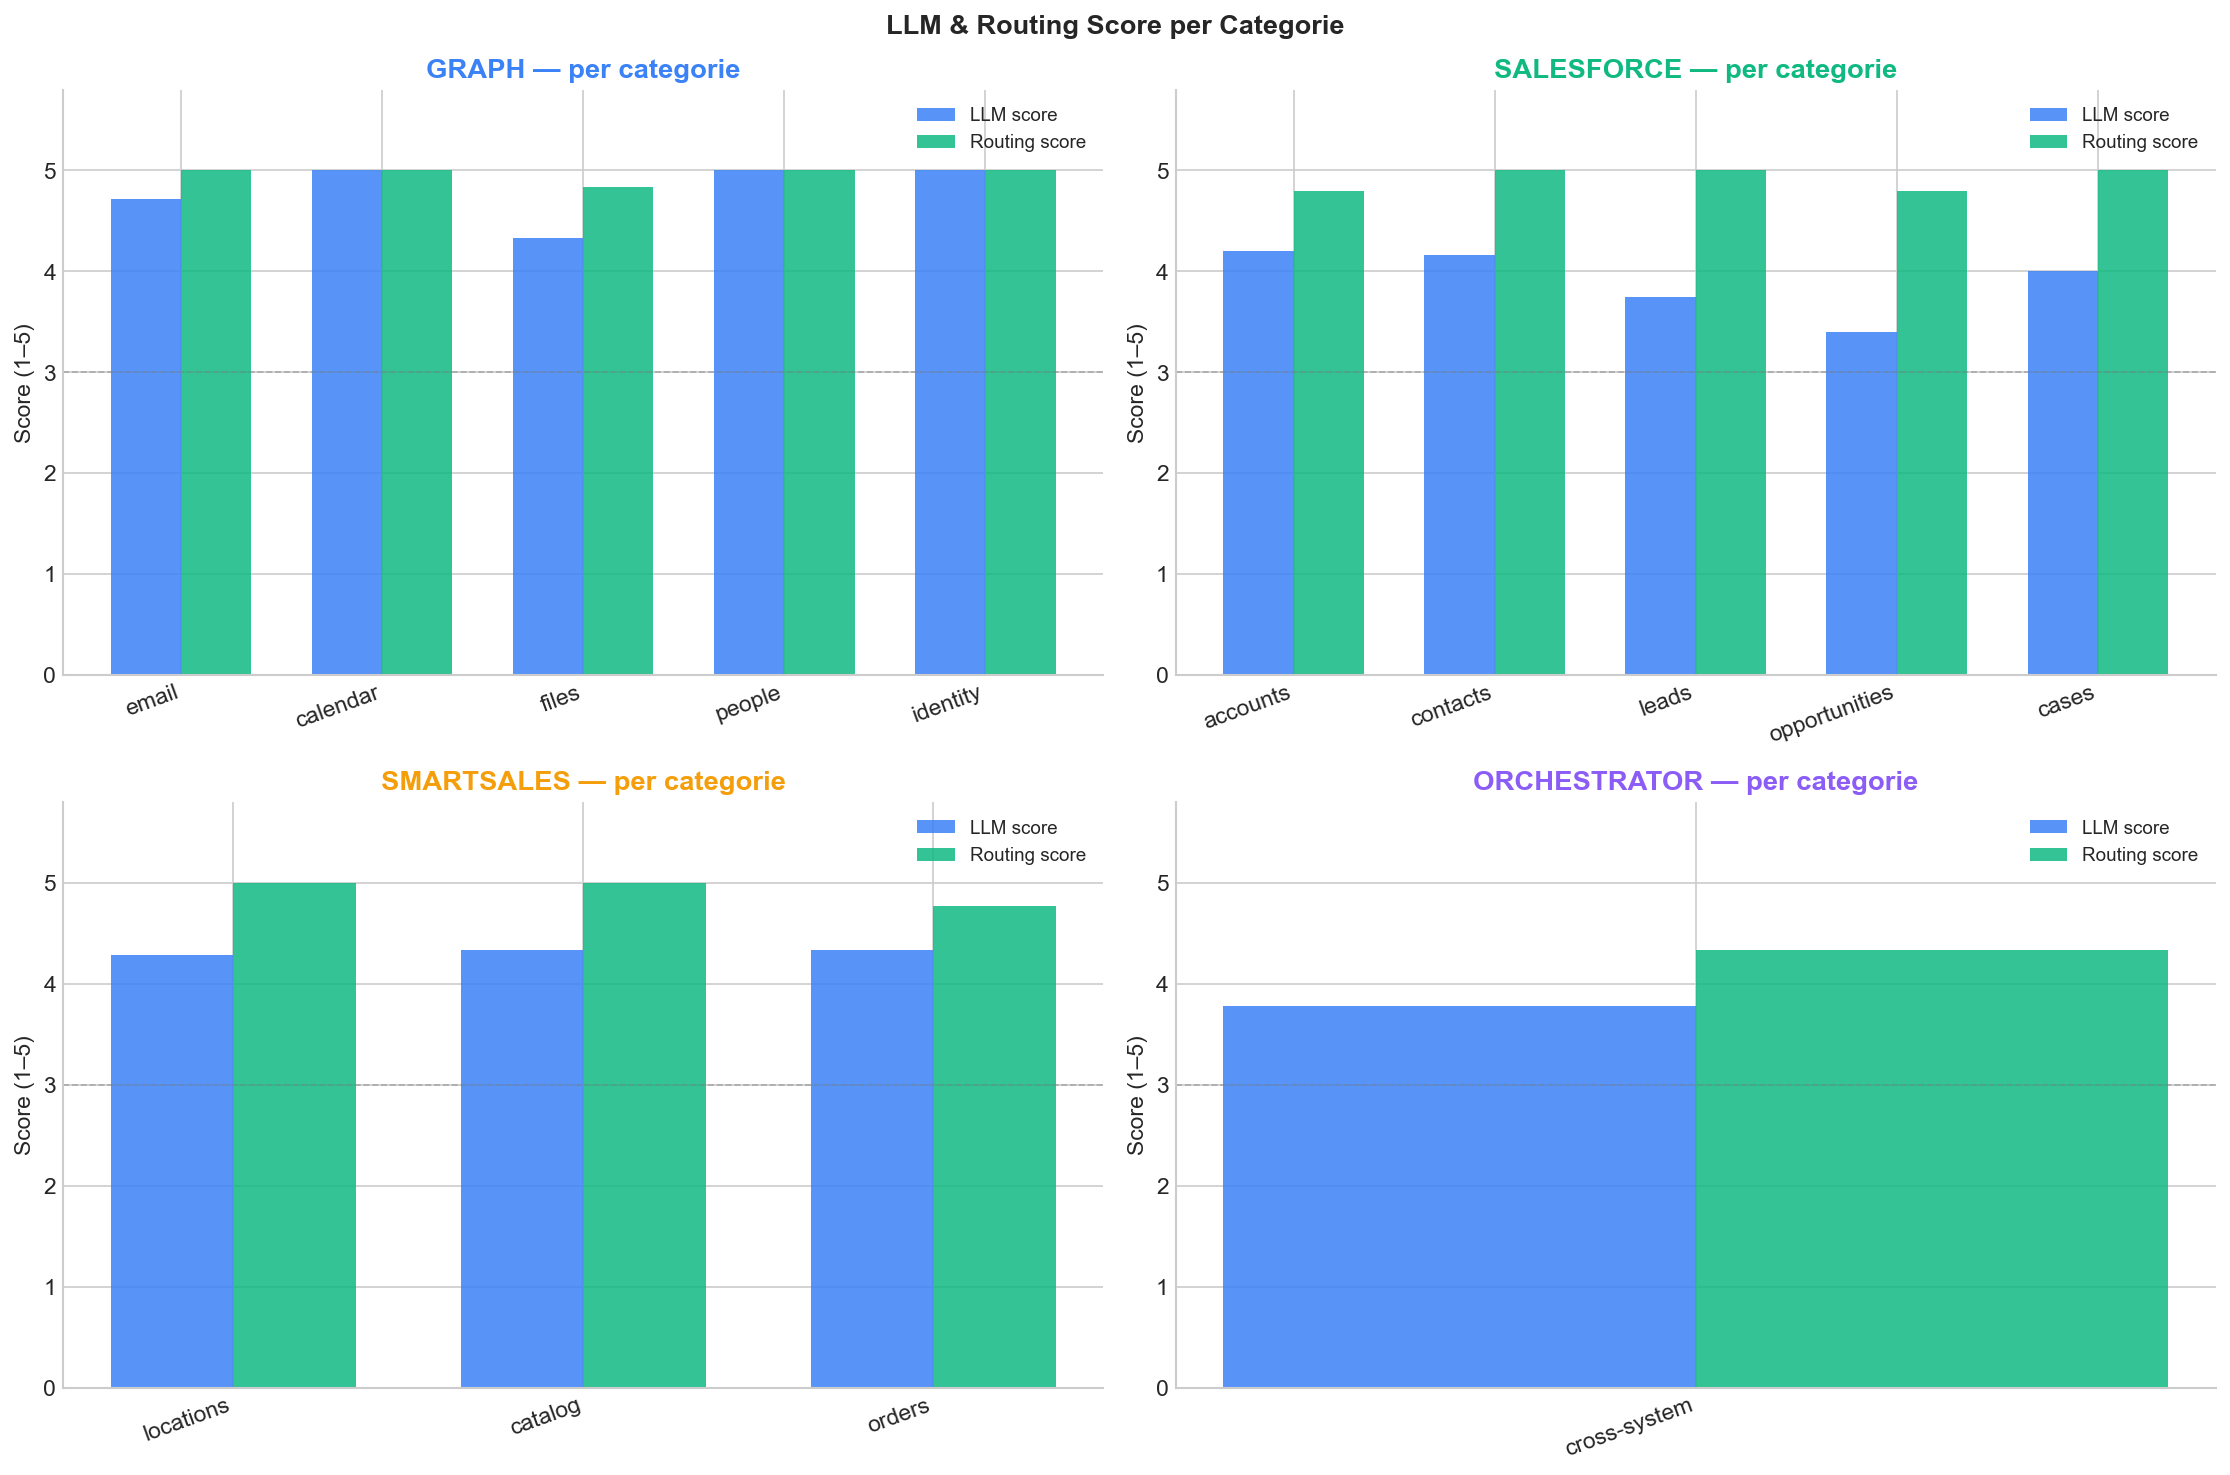

In [196]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for ax_idx, group in enumerate(GROUP_ORDER):
    ax   = axes[ax_idx]
    cats = AGENT_GROUPS[group]
    gdf  = df[df['agent_group'] == group]
    x    = np.arange(len(cats))
    w    = 0.35

    if N_VERSIONS == 1:
        version = VERSIONS[0]
        vdf = gdf[gdf['version'] == version]
        llm_vals  = [vdf[vdf['category'] == c]['llm_score'].mean() for c in cats]
        rout_vals = [vdf[vdf['category'] == c]['routing_score'].mean() for c in cats]
        ax.bar(x - w/2, llm_vals,  w, label='LLM score',    color='#3b82f6', alpha=0.85)
        ax.bar(x + w/2, rout_vals, w, label='Routing score', color='#10b981', alpha=0.85)
    else:
        for v_idx, version in enumerate(VERSIONS):
            vdf = gdf[gdf['version'] == version]
            llm_vals  = [vdf[vdf['category'] == c]['llm_score'].mean() for c in cats]
            rout_vals = [vdf[vdf['category'] == c]['routing_score'].mean() for c in cats]
            off = (v_idx - (N_VERSIONS - 1) / 2) * w * 1.05
            ax.bar(x + off - w/4, llm_vals,  w/2, label=f'{version} LLM',     alpha=0.85)
            ax.bar(x + off + w/4, rout_vals, w/2, label=f'{version} Routing', alpha=0.70)

    ax.set_xticks(x)
    ax.set_xticklabels(cats, rotation=20, ha='right')
    ax.set_ylim(0, 5.8)
    ax.set_ylabel('Score (1–5)')
    ax.set_title(f'{group.upper()} — per categorie', fontweight='bold',
                 color=GROUP_COLORS[group])
    ax.axhline(3, ls='--', color='gray', lw=0.8, alpha=0.5)
    ax.legend(fontsize=9)

plt.suptitle('LLM & Routing Score per Categorie', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('plot_scores_per_category.png', bbox_inches='tight')
plt.show()

## 4. Score per moeilijkheidsgraad

C:\Users\AALB\AppData\Local\Temp\ipykernel_25672\2040873186.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['agent_group', 'difficulty'])[metric]
C:\Users\AALB\AppData\Local\Temp\ipykernel_25672\2040873186.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['agent_group', 'difficulty'])[metric]


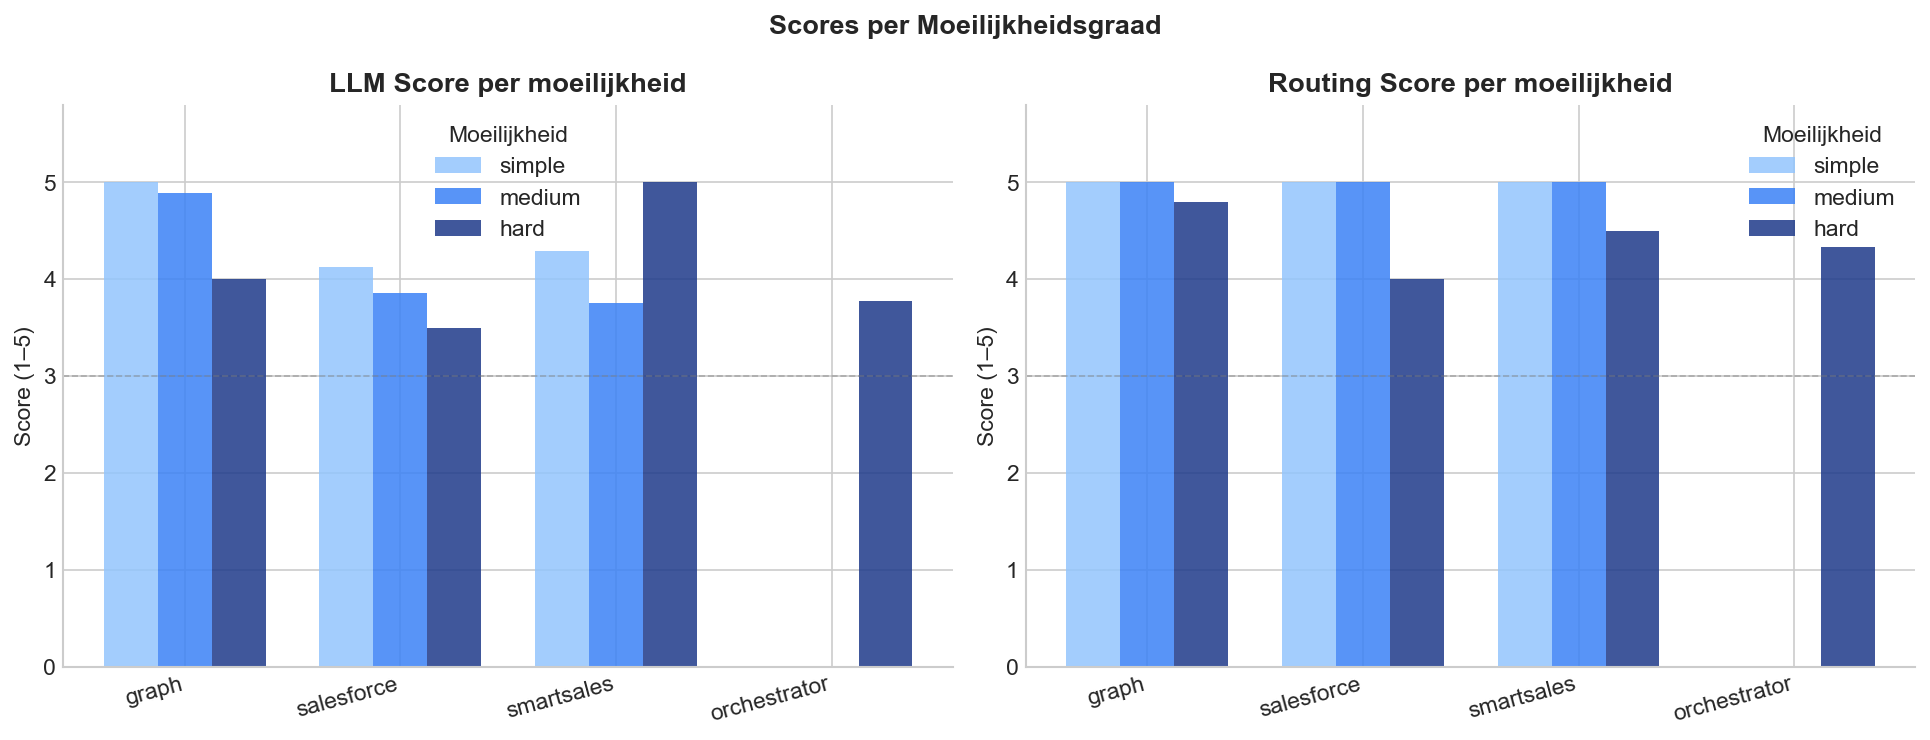

In [197]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax_idx, (metric, title) in enumerate([
    ('llm_score',     'LLM Score per moeilijkheid'),
    ('routing_score', 'Routing Score per moeilijkheid'),
]):
    ax = axes[ax_idx]
    pivot = (
        df.groupby(['agent_group', 'difficulty'])[metric]
        .mean()
        .unstack('difficulty')
        .reindex(GROUP_ORDER)
        .reindex(columns=DIFFICULTY_ORDER)
    )
    x = np.arange(len(GROUP_ORDER))
    w = 0.25
    for d_idx, diff in enumerate(DIFFICULTY_ORDER):
        vals = pivot[diff].values if diff in pivot.columns else [np.nan] * len(GROUP_ORDER)
        off  = (d_idx - 1) * w
        ax.bar(x + off, vals, w, label=diff, color=DIFF_COLORS[diff], alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(GROUP_ORDER, rotation=15, ha='right')
    ax.set_ylim(0, 5.8)
    ax.set_ylabel('Score (1–5)')
    ax.set_title(title, fontweight='bold')
    ax.axhline(3, ls='--', color='gray', lw=0.8, alpha=0.5)
    ax.legend(title='Moeilijkheid')

plt.suptitle('Scores per Moeilijkheidsgraad', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('plot_scores_by_difficulty.png', bbox_inches='tight')
plt.show()

## 5. Latency per agent group

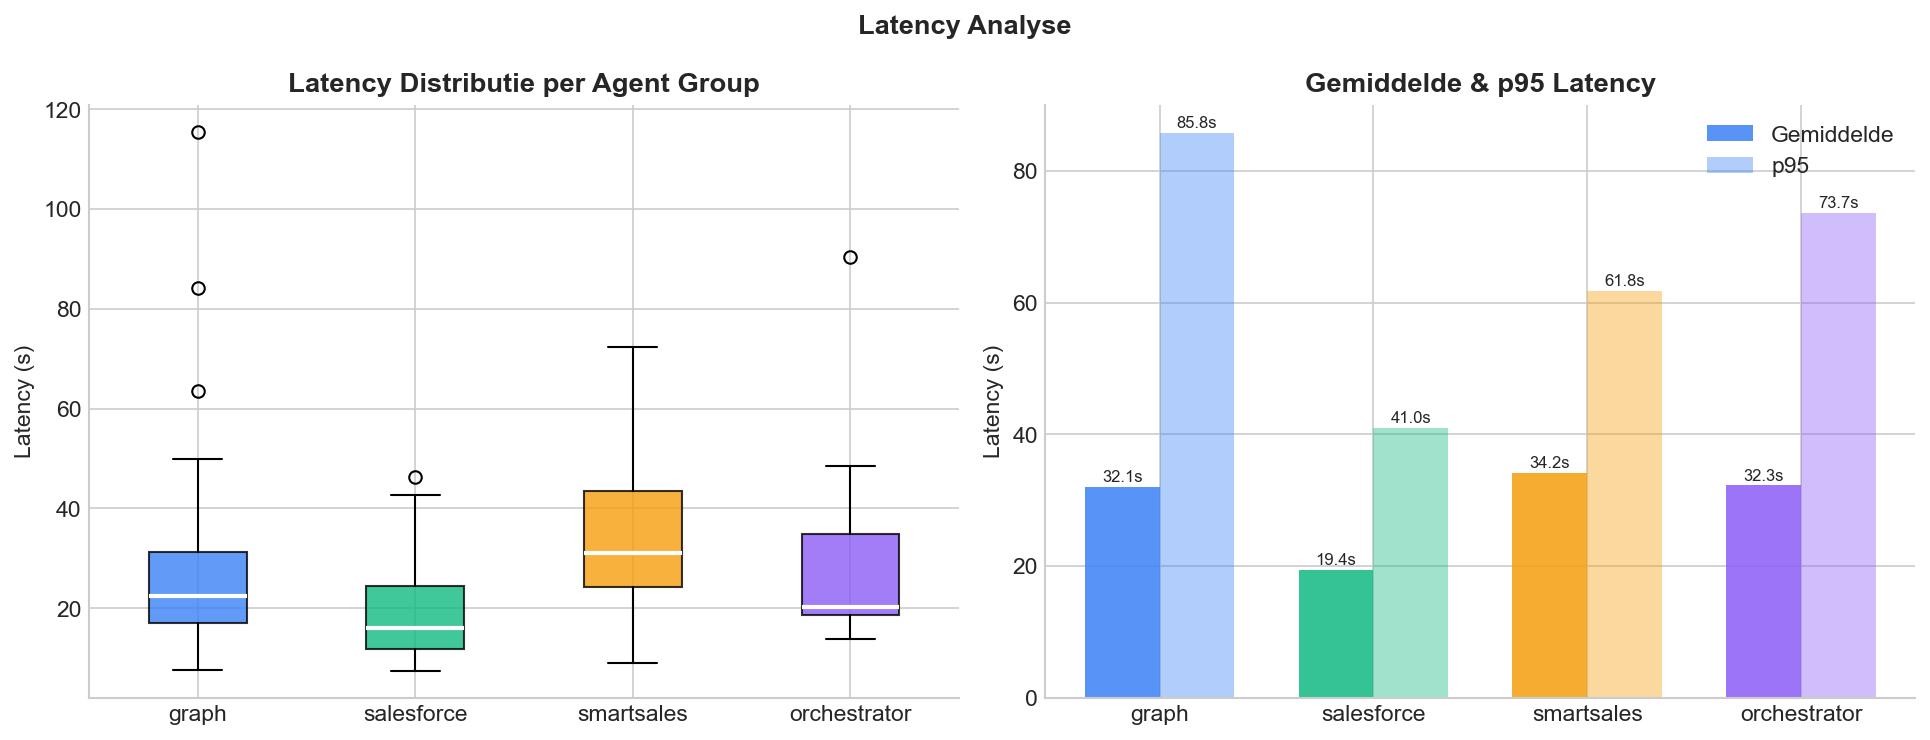

In [198]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Boxplot
ax = axes[0]
box_data = [df[df['agent_group'] == g]['latency_s'].dropna().values for g in GROUP_ORDER]
bp = ax.boxplot(box_data, patch_artist=True, medianprops=dict(color='white', lw=2))
for patch, grp in zip(bp['boxes'], GROUP_ORDER):
    patch.set_facecolor(GROUP_COLORS[grp])
    patch.set_alpha(0.8)
ax.set_xticklabels(GROUP_ORDER)
ax.set_ylabel('Latency (s)')
ax.set_title('Latency Distributie per Agent Group', fontweight='bold')

# Gemiddelde + p95
ax = axes[1]
x     = np.arange(len(GROUP_ORDER))
w     = 0.35
means = [df[df['agent_group'] == g]['latency_s'].mean() for g in GROUP_ORDER]
p95s  = [df[df['agent_group'] == g]['latency_s'].quantile(0.95) for g in GROUP_ORDER]

b1 = ax.bar(x - w/2, means, w, label='Gemiddelde',
            color=[GROUP_COLORS[g] for g in GROUP_ORDER], alpha=0.85)
b2 = ax.bar(x + w/2, p95s,  w, label='p95',
            color=[GROUP_COLORS[g] for g in GROUP_ORDER], alpha=0.4)

for bar, val in zip(list(b1) + list(b2), means + p95s):
    if not (val != val):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                f'{val:.1f}s', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(GROUP_ORDER)
ax.set_ylabel('Latency (s)')
ax.set_title('Gemiddelde & p95 Latency', fontweight='bold')
ax.legend()

plt.suptitle('Latency Analyse', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('plot_latency.png', bbox_inches='tight')
plt.show()

## 6. Token gebruik & geschatte kost

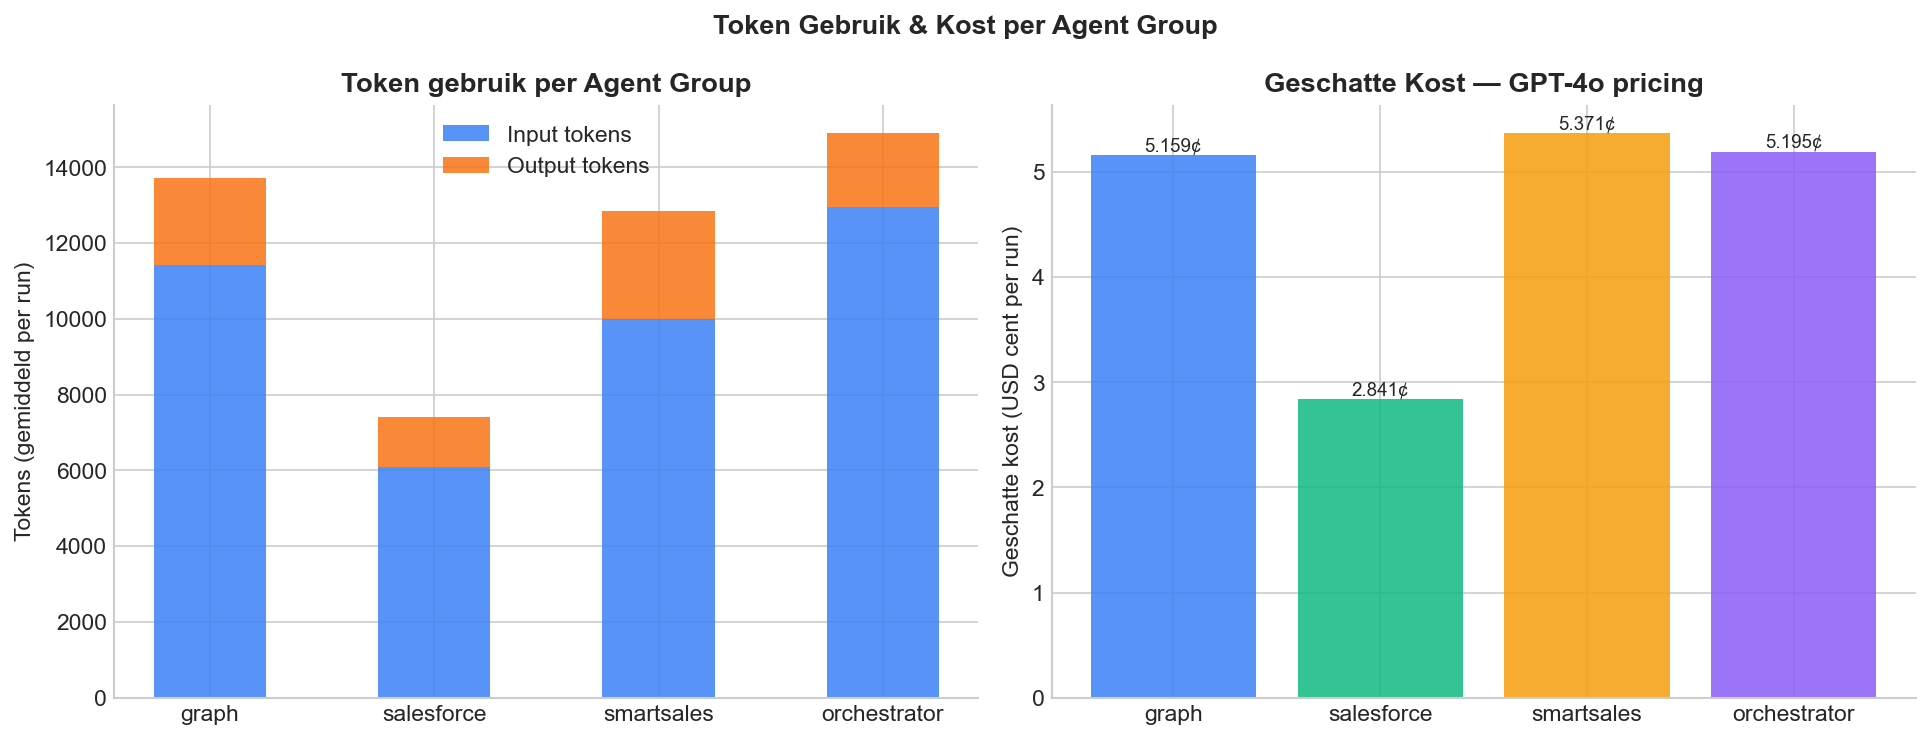

Totale geschatte kost voor deze run(s): $3.3627 USD (336.27 cent)


In [199]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Tokens (stacked)
ax = axes[0]
x       = np.arange(len(GROUP_ORDER))
in_tok  = [df[df['agent_group'] == g]['input_tokens'].mean() for g in GROUP_ORDER]
out_tok = [df[df['agent_group'] == g]['output_tokens'].mean() for g in GROUP_ORDER]
ax.bar(x, in_tok,  0.5, label='Input tokens',  color='#3b82f6', alpha=0.85)
ax.bar(x, out_tok, 0.5, bottom=in_tok, label='Output tokens', color='#f97316', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(GROUP_ORDER)
ax.set_ylabel('Tokens (gemiddeld per run)')
ax.set_title('Token gebruik per Agent Group', fontweight='bold')
ax.legend()

# Kost (USD cent)
ax = axes[1]
costs = [df[df['agent_group'] == g]['cost_usd'].mean() * 100 for g in GROUP_ORDER]
bars  = ax.bar(x, costs, color=[GROUP_COLORS[g] for g in GROUP_ORDER], alpha=0.85)
for bar, val in zip(bars, costs):
    if not (val != val):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
                f'{val:.3f}¢', ha='center', va='bottom', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(GROUP_ORDER)
ax.set_ylabel('Geschatte kost (USD cent per run)')
ax.set_title('Geschatte Kost — GPT-4o pricing', fontweight='bold')

plt.suptitle('Token Gebruik & Kost per Agent Group', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('plot_tokens_cost.png', bbox_inches='tight')
plt.show()

total_cost = df['cost_usd'].sum()
print(f'Totale geschatte kost voor deze run(s): ${total_cost:.4f} USD ({total_cost*100:.2f} cent)')

## 7. Routing Precision & Recall per agent group

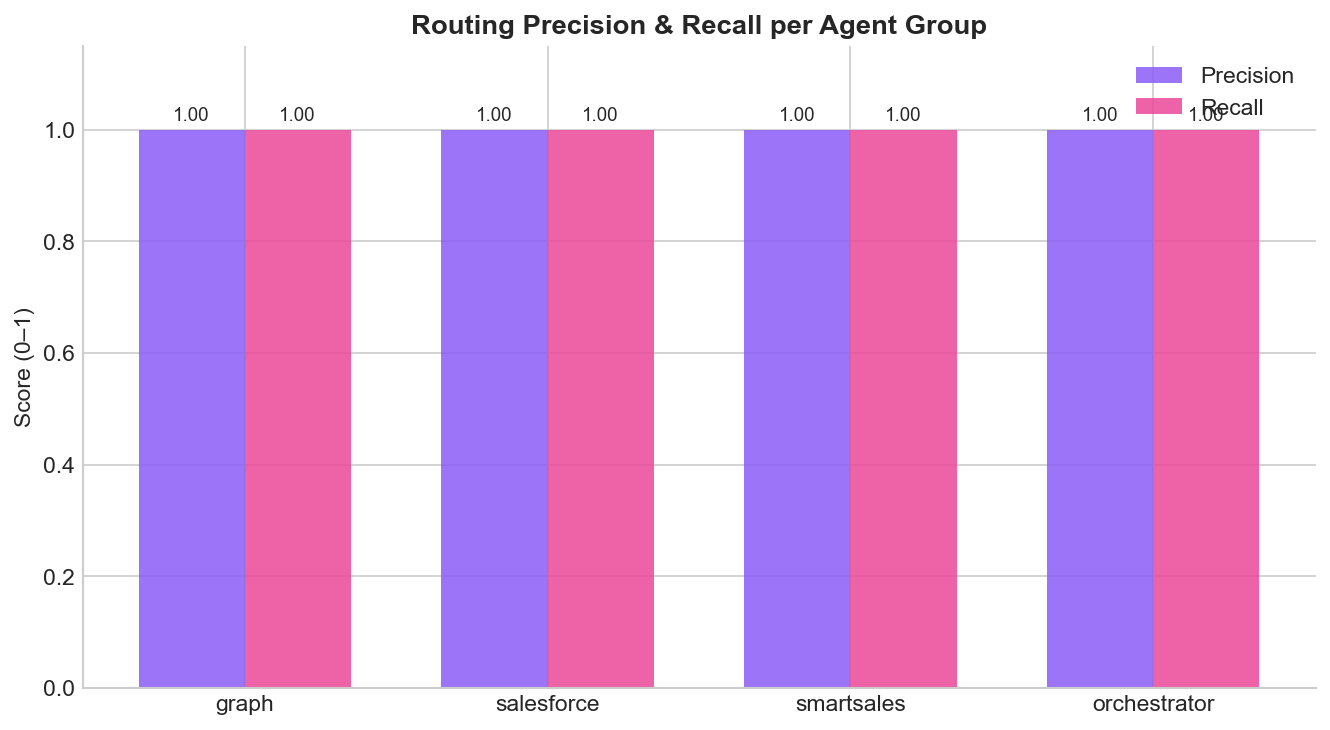

In [200]:
fig, ax = plt.subplots(figsize=(9, 5))
x    = np.arange(len(GROUP_ORDER))
w    = 0.35
prec = [df[df['agent_group'] == g]['routing_precision'].mean() for g in GROUP_ORDER]
rec  = [df[df['agent_group'] == g]['routing_recall'].mean() for g in GROUP_ORDER]

b1 = ax.bar(x - w/2, prec, w, label='Precision', color='#8b5cf6', alpha=0.85)
b2 = ax.bar(x + w/2, rec,  w, label='Recall',    color='#ec4899', alpha=0.85)

for bar, val in zip(list(b1) + list(b2), prec + rec):
    if not (val != val):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(GROUP_ORDER)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score (0–1)')
ax.set_title('Routing Precision & Recall per Agent Group', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('plot_routing_precision_recall.png', bbox_inches='tight')
plt.show()

## 8. Slechtst scorende cases + rationale

In [201]:
LOW_THRESHOLD = 2  # pas aan om meer/minder cases te zien

low = (
    df[df['llm_score'] <= LOW_THRESHOLD]
    .sort_values(['agent_group', 'llm_score', 'difficulty'])
    .assign(run_id_short=lambda d: d['run_id'].str[:8])
    [['run_name', 'run_id_short', 'version', 'agent_group', 'category', 'difficulty',
      'llm_score', 'routing_score', 'query', 'llm_rationale']]
    .reset_index(drop=True)
)

print(f'Cases met llm_score <= {LOW_THRESHOLD}: {len(low)} / {len(df)}')

pd.set_option('display.max_colwidth', 120)
pd.set_option('display.max_rows', 60)

display(
    low.style
    .map(
        lambda v: 'background-color:#fee2e2' if v == 1 else
                  ('background-color:#fef9c3' if v == 2 else ''),
        subset=['llm_score', 'routing_score'],
    )
    .set_properties(**{'text-align': 'left', 'white-space': 'pre-wrap'})
    .set_caption(f'Lage-score cases (llm_score <= {LOW_THRESHOLD})')
)

# ── Volledige run_ids afdrukken ───────────────────────────────────────────────
full_ids = (
    df[df['llm_score'] <= LOW_THRESHOLD]
    .sort_values(['agent_group', 'llm_score'])
    [['run_name', 'run_id']]
    .reset_index(drop=True)
)

print('\n── Run IDs ──')
for _, row in full_ids.iterrows():
    name = row.get('run_name') or '?'
    print(f"  {name:<35}  {row['run_id']}")

Cases met llm_score <= 2: 3 / 76


,run_name,run_id_short,version,agent_group,category,difficulty,llm_score,routing_score,query,llm_rationale
0,tc06_leads_medium,8e3b5b21,baseline,salesforce,leads,medium,2.000000,5.000000,Find Salesforce leads from the Technology or Software industry.,"The response indicates that no leads were found, which is partially correct but does not fulfill the request for a list of leads from the specified industries."
1,tc09_locations_simple,d690b36c,baseline,smartsales,locations,simple,2.000000,5.000000,List all SmartSales locations.,The response provides a list of locations but fails to present the data in the required JSON format and does not include the uid field for each location.
2,tc07_orders_simple,eb407142,baseline,smartsales,orders,simple,2.000000,5.000000,List recent SmartSales orders.,"The response provides detailed information about recent SmartSales orders but does not present the data in the required JSON format, which is a major gap."



── Run IDs ──
  tc06_leads_medium                    8e3b5b2177d24de0aba55208b9d7c555
  tc09_locations_simple                d690b36cea6740288b678d5635a3d43f
  tc07_orders_simple                   eb40714274c54db49f7d957bda430ee3


In [202]:
for run_id in [
    "9e269d02a2254a09bf24403d4ae227bc",  # tc01_cross-system_hard
    "035a432652a64dc4b26c1c01cdc076d4",  # tc01_cross-system_hard

]:
    mlflow.delete_run(run_id)

## 9. Cross-system / Orchestrator deep dive

Cross-system cases: 9


,version,difficulty,llm_score,routing_score,plan_steps,parallel_ratio,latency_s,total_tokens
0,baseline,hard,3.0,4.0,2.0,0.500,19.750,10066.0
1,baseline,hard,3.0,5.0,2.0,0.500,18.690,6681.0
2,baseline,hard,3.0,5.0,3.0,1.000,13.920,10338.0
3,baseline,hard,4.0,4.0,2.0,0.500,20.163,11940.0
4,baseline,hard,4.0,5.0,2.0,0.500,34.896,21312.0
5,baseline,hard,4.0,5.0,3.0,0.333,14.582,16622.0
6,baseline,hard,4.0,3.0,3.0,0.667,29.291,16807.0
7,baseline,hard,4.0,3.0,2.0,0.500,48.532,9961.0
8,baseline,hard,5.0,5.0,2.0,1.000,90.452,30443.0


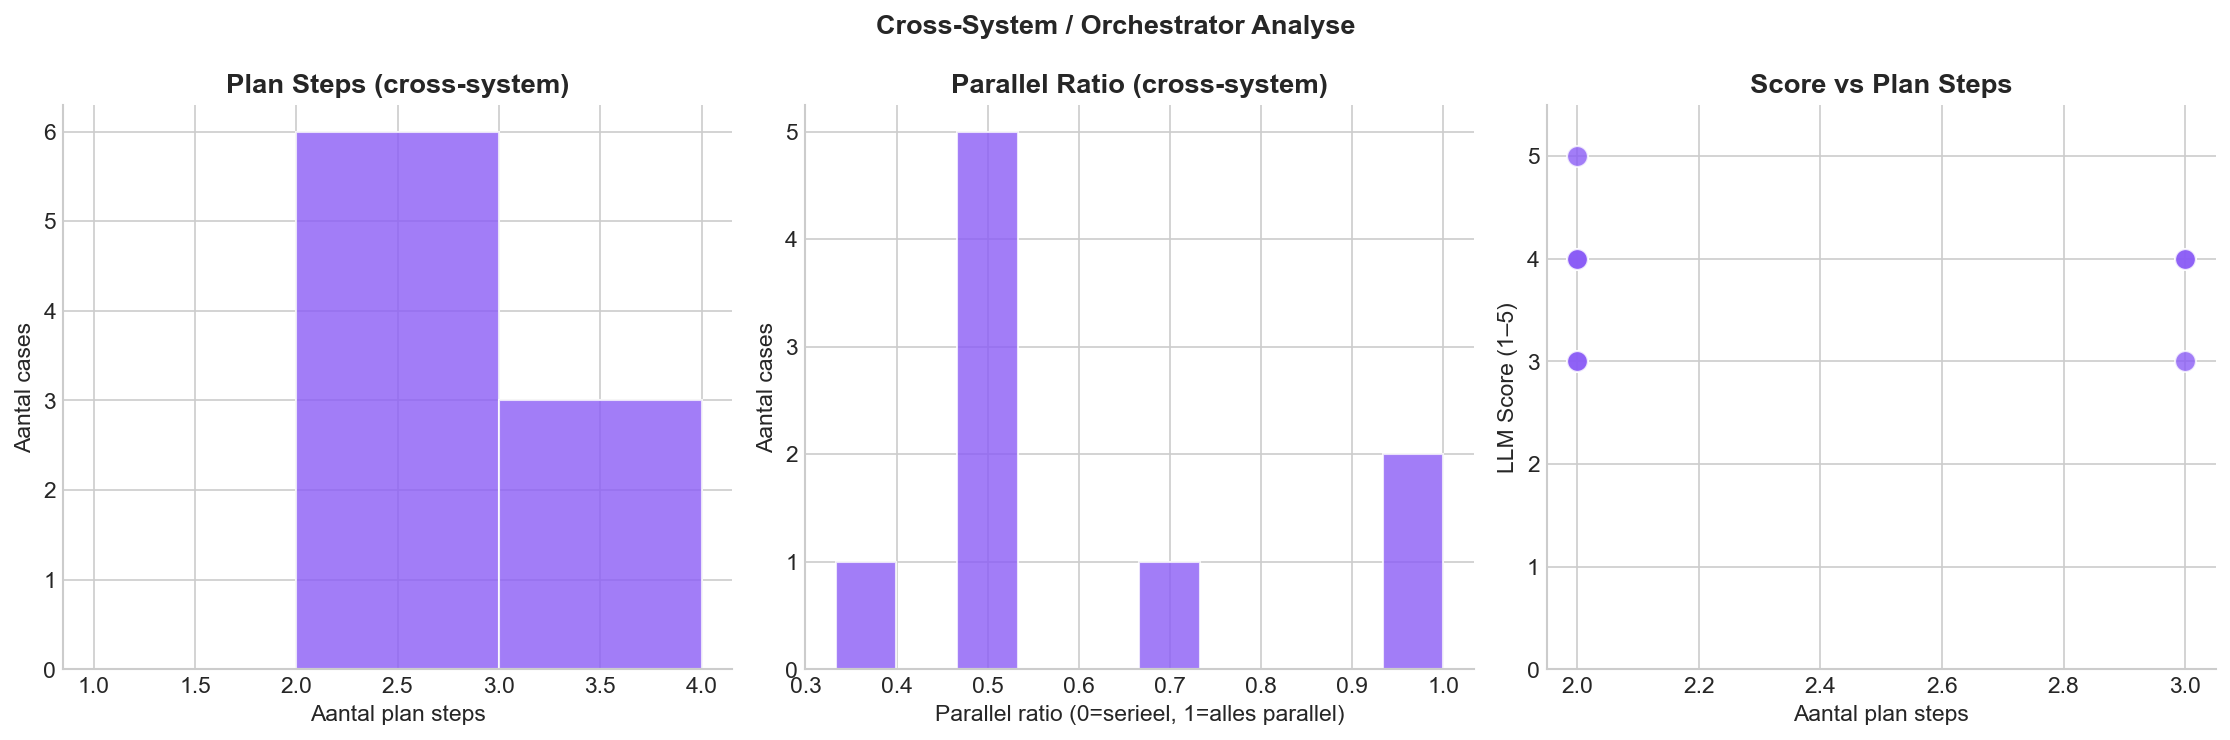

In [203]:
cross = df[df['agent_group'] == 'orchestrator'].copy()
print(f'Cross-system cases: {len(cross)}')
display(cross[['version', 'difficulty', 'llm_score', 'routing_score',
               'plan_steps', 'parallel_ratio', 'latency_s', 'total_tokens']]
        .sort_values('llm_score').reset_index(drop=True))

if len(cross) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Verdeling plan steps
    ax = axes[0]
    bins = range(1, int(cross['plan_steps'].max() + 2)) if cross['plan_steps'].notna().any() else range(1, 6)
    ax.hist(cross['plan_steps'].dropna(), bins=bins, color='#8b5cf6', alpha=0.8, edgecolor='white')
    ax.set_xlabel('Aantal plan steps')
    ax.set_ylabel('Aantal cases')
    ax.set_title('Plan Steps (cross-system)', fontweight='bold')

    # Parallel ratio
    ax = axes[1]
    ax.hist(cross['parallel_ratio'].dropna(), bins=10, color='#8b5cf6', alpha=0.8, edgecolor='white')
    ax.set_xlabel('Parallel ratio (0=serieel, 1=alles parallel)')
    ax.set_ylabel('Aantal cases')
    ax.set_title('Parallel Ratio (cross-system)', fontweight='bold')

    # Score vs plan steps scatter
    ax = axes[2]
    ax.scatter(cross['plan_steps'], cross['llm_score'],
               c='#8b5cf6', s=100, alpha=0.8, edgecolors='white', zorder=3)
    ax.set_xlabel('Aantal plan steps')
    ax.set_ylabel('LLM Score (1–5)')
    ax.set_ylim(0, 5.5)
    ax.set_title('Score vs Plan Steps', fontweight='bold')

    plt.suptitle('Cross-System / Orchestrator Analyse', fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.savefig('plot_cross_system.png', bbox_inches='tight')
    plt.show()

## 10. Versievergelijking (baseline vs v1 …)

In [204]:
if N_VERSIONS < 2:
    print(f'Slechts 1 versie gevonden ({VERSIONS[0]}). Run mlflow_eval.py met --version v1 voor vergelijking.')
else:
    metrics_to_compare = [
        ('llm_score',         'LLM Score (1–5)',    (0, 5.5)),
        ('routing_score',     'Routing Score (1–5)', (0, 5.5)),
        ('latency_s',         'Latency (s)',          None),
        ('total_tokens',      'Total Tokens',         None),
        ('routing_precision', 'Precision (0–1)',      (0, 1.1)),
        ('routing_recall',    'Recall (0–1)',         (0, 1.1)),
    ]

    n_cols = 3
    n_rows = (len(metrics_to_compare) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4.5))
    axes = axes.flatten()

    for ax_idx, (metric, label, ylim) in enumerate(metrics_to_compare):
        ax    = axes[ax_idx]
        x     = np.arange(len(GROUP_ORDER))
        bar_w = 0.7 / N_VERSIONS
        for v_idx, version in enumerate(VERSIONS):
            vdf  = df[df['version'] == version]
            vals = [vdf[vdf['agent_group'] == g][metric].mean() for g in GROUP_ORDER]
            off  = (v_idx - (N_VERSIONS - 1) / 2) * bar_w
            ax.bar(x + off, vals, bar_w, label=version, alpha=0.85)
        ax.set_xticks(x)
        ax.set_xticklabels(GROUP_ORDER, rotation=15, ha='right')
        ax.set_ylabel(label)
        ax.set_title(label, fontweight='bold')
        if ylim:
            ax.set_ylim(*ylim)
        ax.legend(fontsize=8)

    for i in range(len(metrics_to_compare), len(axes)):
        axes[i].set_visible(False)

    plt.suptitle(f'Versievergelijking: {", ".join(VERSIONS)}', fontweight='bold', fontsize=14)
    plt.tight_layout()
    plt.savefig('plot_version_comparison.png', bbox_inches='tight')
    plt.show()

    # Delta tabel
    print(f'\n── Delta ({VERSIONS[-1]} − {VERSIONS[0]}) per agent group ──')
    for metric in ['llm_score', 'routing_score', 'latency_s', 'total_tokens']:
        base  = df[df['version'] == VERSIONS[0]].groupby('agent_group')[metric].mean()
        comp  = df[df['version'] == VERSIONS[-1]].groupby('agent_group')[metric].mean()
        delta = (comp - base).reindex(GROUP_ORDER).round(3)
        print(f'\n{metric}:')
        print(delta.to_string())

Slechts 1 versie gevonden (baseline). Run mlflow_eval.py met --version v1 voor vergelijking.


## 11. Prompt coverage — welke prompts zijn al gerund?

In [205]:
import json as _json
import os as _os
from collections import Counter as _Counter

# Pad naar prompts-bestand (afgeleid van TRACKING_URI)
_project_root = _os.path.dirname(TRACKING_URI.replace('sqlite:///', ''))
_prompts_file = _os.path.join(_project_root, 'eval', 'all_prompts.json')
if not _os.path.exists(_prompts_file):
    _prompts_file = 'eval/all_prompts.json'

with open(_prompts_file, encoding='utf-8') as _f:
    _all_prompts = _json.load(_f)

print(f'Prompts-bestand : {_prompts_file}')
print(f'Totaal verwacht : {len(_all_prompts)} prompts')

_fp = lambda text: text.strip()[:200]
_expected = {_fp(p['text']): p for p in _all_prompts}

CHECK_VERSION = VERSIONS[0]  # aanpassen naar bijv. 'v1'
print(f'Versie checken  : {CHECK_VERSION}')

_vdf = df[df['version'] == CHECK_VERSION].copy()
_run_fps = set()
if 'query' in _vdf.columns:
    _run_fps = {_fp(str(q)) for q in _vdf['query'].dropna()}

_missing, _found = [], []
for _key, _p in _expected.items():
    _matched = any(_key.startswith(_r) or _r.startswith(_key) for _r in _run_fps)
    (_found if _matched else _missing).append(_p)

print(f'Gerund          : {len(_found)}')
print(f'Ontbrekend      : {len(_missing)}')
print()

if not _missing:
    print('Alle prompts zijn gerund!')
else:
    _miss_df = pd.DataFrame(_missing)[['category', 'difficulty', 'text']].copy()
    _miss_df['text'] = _miss_df['text'].str[:100]
    _miss_df = _miss_df.sort_values(['category', 'difficulty']).reset_index(drop=True)
    display(_miss_df)
    print()
    print('=== Commando per ontbrekende categorie ===')
    for _cat, _n in sorted(_Counter(p['category'] for p in _missing).items()):
        print(f'  python eval/mlflow_eval.py --version {CHECK_VERSION} --category {_cat}  # {_n} prompt(s)')

if 'query' in _vdf.columns:
    _dup_counts = _vdf['query'].dropna().apply(_fp).value_counts()
    _dupes = _dup_counts[_dup_counts > 1]
    print()
    if not _dupes.empty:
        print('=== Dubbele runs ===')
        for _key, _cnt in _dupes.items():
            _rows = _vdf[_vdf['query'].apply(lambda q: _fp(str(q))) == _key]
            _ids  = ', '.join(_rows['run_id'].str[:8].tolist())
            print(f'  [{_cnt}x] {_key[:80]}')
            print(f'         run_ids: {_ids}')
    else:
        print('Geen dubbele runs.')

Prompts-bestand : C:/Users/AALB/Desktop/mp/graph/graphxmaf\eval\all_prompts.json
Totaal verwacht : 75 prompts
Versie checken  : baseline
Gerund          : 75
Ontbrekend      : 0

Alle prompts zijn gerund!

Geen dubbele runs.


## 12. Dubbele runs vergelijken — welke bewaren / verwijderen?

In [206]:
# Plak hier de run_ids (8-char) uit cel 11 — alle duplicates bij elkaar
DUPLICATE_RUN_IDS = [
    "494d7b38", "762e805b", "20916827",  # Find Salesforce accounts in France...
    "5c684c4b"
]

# ── Match korte IDs naar volledige run_ids ────────────────────────────────────
_short_to_full = {rid[:8]: rid for rid in df['run_id']}
_full_ids = list({_short_to_full[s] for s in DUPLICATE_RUN_IDS if s in _short_to_full})

COLS = ['run_name', 'run_id', 'category', 'difficulty',
        'llm_score', 'routing_score', 'latency_s', 'total_tokens', 'success', 'llm_rationale']
_show_cols = [c for c in COLS if c in df.columns]

_dup_df = (
    df[df['run_id'].isin(_full_ids)]
    .sort_values(['category', 'difficulty', 'llm_score'], ascending=[True, True, False])
    [_show_cols]
    .reset_index(drop=True)
)

pd.set_option('display.max_colwidth', 100)
print(f'{len(_dup_df)} runs gevonden\n')

display(
    _dup_df.style
    .map(
        lambda v: 'background-color:#d1fae5' if isinstance(v, float) and v >= 4 else
                  ('background-color:#fee2e2' if isinstance(v, float) and v <= 2 else ''),
        subset=[c for c in ['llm_score', 'routing_score'] if c in _dup_df.columns],
    )
    .set_properties(**{'text-align': 'left', 'white-space': 'pre-wrap'})
    .set_caption('Groen = score >= 4 | Rood = score <= 2')
)

# ── Automatisch beste run per prompt selecteren ───────────────────────────────
# Keuze: hoogste llm_score, bij gelijkspel laagste latency
_keep, _delete = [], []
if 'query' in df.columns:
    _dup_full = df[df['run_id'].isin(_full_ids)].copy()
    _dup_full['_fp'] = _dup_full['query'].fillna('').apply(lambda t: t.strip()[:200])

    print('=== Aanbevolen bewaren / verwijderen ===')
    for _fp_key, _grp in _dup_full.groupby('_fp'):
        _grp_sorted = _grp.sort_values(
            ['llm_score', 'routing_score', 'latency_s'],
            ascending=[False, False, True],
        )
        _best = _grp_sorted.iloc[0]
        _rest = _grp_sorted.iloc[1:]
        _keep.append(_best['run_id'])
        _delete.extend(_rest['run_id'].tolist())
        _label = (_best.get('run_name') or _best['run_id'][:8])
        print(f'  KEEP  {_label:<38} llm={_best["llm_score"]}/5  lat={_best["latency_s"]:.1f}s')
        for _, _r in _rest.iterrows():
            _rl = (_r.get('run_name') or _r['run_id'][:8])
            print(f'  DEL   {_rl:<38} llm={_r["llm_score"]}/5  lat={_r["latency_s"]:.1f}s')

    print(f'\n=== Verwijder {len(_delete)} run(s) — uncomment en run ===')
    print('# mlflow.set_tracking_uri(TRACKING_URI)')
    print('# for run_id in [')
    for _rid in _delete:
        _rname = (df[df['run_id'] == _rid]['run_name'].iloc[0]
                  if 'run_name' in df.columns else '')
        print(f'#     "{_rid}",  # {_rname}')
    print('# ]:')
    print('#     mlflow.delete_run(run_id)')

2 runs gevonden



,run_name,run_id,category,difficulty,llm_score,routing_score,latency_s,total_tokens,success,llm_rationale
0,tc00_cross-system_hard,494d7b388fe247418652f22267382916,cross-system,hard,4.000000,3.000000,48.532000,9961.000000,1.000000,"The response correctly identifies the most recently modified OneDrive file and provides a link, but it lacks details about the content of the file and does not specify any company names that were checked against Salesforce accounts."
1,tc01_cross-system_hard,209168276dd74633a542db695cd689e4,cross-system,hard,4.000000,5.000000,14.582000,16622.000000,1.000000,"The response correctly identifies the sender's name and email, and provides the results of the Salesforce and SmartSales checks. However, it could improve by explicitly stating the company name associated with the sender for clarity."


=== Aanbevolen bewaren / verwijderen ===
  KEEP  tc00_cross-system_hard                 llm=4.0/5  lat=48.5s
  KEEP  tc01_cross-system_hard                 llm=4.0/5  lat=14.6s

=== Verwijder 0 run(s) — uncomment en run ===
# mlflow.set_tracking_uri(TRACKING_URI)
# for run_id in [
# ]:
#     mlflow.delete_run(run_id)


In [207]:
# mlflow.set_tracking_uri(TRACKING_URI)
# for run_id in [
#     "762e805b2722485f89d221b56d67771e",
#     "5c684c4b03854b0d89b7fd6973e5f19b",

# ]:
#     mlflow.delete_run(run_id)